## Drones Automatisation

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import itertools
from networkx.algorithms.matching import max_weight_matching
import random
import pickle
import osmnx as ox
import time

In [2]:
#Animation

import time
from IPython.display import clear_output

In [3]:
def save_graph(G, nom_fichier):
    nom_fichier = nom_fichier.replace(" ", "-")
    with open(nom_fichier, 'wb') as f:
        pickle.dump(G, f, pickle.HIGHEST_PROTOCOL)
    print(f"Graphe du quartier sauvegardé dans : {nom_fichier}")

In [4]:
def fetch_arrondissement(arrondissement):
    quartier = arrondissement + ", Montréal, Québec, Canada"
    G = ox.graph_from_place(quartier, network_type="drive")
    G = ox.distance.add_edge_lengths(G)
    return G

In [5]:
def import_G(filename):
    #filename = "plateau_mont_royal.gpickle"
    
    with open(filename, 'rb') as f:
        G = pickle.load(f).to_undirected()
    return G

In [6]:
def snowize(G, p = 0.5):
    for u, v in G.edges():
        for key in G[u][v]:
            if (random.random() <= p):
                G[u][v][key]['snow'] = 1
            else:
                G[u][v][key]['snow'] = 0
    return G

In [7]:
def eulerize(G):
    # G_bis = copie de G en Multigraph
    # G_aug = G euleuriser
    G_bis = nx.MultiGraph(G)
    
    # Trouver les sommets de degre impair
    odd_nodes = [v for v, d in G_bis.degree() if d % 2 == 1]
    
    # Generer tous les appariements possibles (pairs sans repetition)
    pairs = list(itertools.combinations(odd_nodes, 2))
    
    # Calculer la distance la plus courte entre chaque paire
    pair_weights = {}
    for u, v in pairs:
        length = nx.dijkstra_path_length(G_bis, u, v, weight='length')
        pair_weights[(u, v)] = length
    
    # Trouver les chemins de distance minimale pour chaque paire de nœuds
    neg_weights = {pair: -w for pair, w in pair_weights.items()}
    matching_graph = nx.Graph([(u, v, {'weight': neg_weights[(u, v)]}) for (u, v) in neg_weights])
    matching = max_weight_matching(matching_graph, maxcardinality=True)
    
    # Ajouter les aretes necessaires (dans un MultiGraph)
    G_aug = nx.MultiGraph(G)  # copie avec aretes multiples autorisees
    for u, v in matching:
        path = nx.dijkstra_path(G, u, v, weight='length')
        path_edges = list(zip(path[:-1], path[1:]))
        for edge in path_edges:
            weight = G_bis[edge[0]][edge[1]][0]['length']
            G_aug.add_edge(edge[0], edge[1], weight=weight)
        
    return G_aug

def circuit(G_aug):
    return list(nx.eulerian_circuit(G_aug))

In [8]:
def snow_roads(G_aug, G_bis):
    circuit = list(nx.eulerian_circuit(G_aug))
    edges = []
    for i, (u, v) in enumerate(circuit):
        for key in G_bis[u][v]:
            if G_bis[u][v][key]['snow']:
                edges.append((u, v, key))

    return edges

In [9]:
def animation(G_aug, arrondissement, snow_edges):
    # Position geographique reelle
    pos = {node: (data['x'], data['y']) for node, data in G_aug.nodes(data=True)}
    
    circuit = list(nx.eulerian_circuit(G_aug))
    
    edges_drawn = []
    
    for i, edge in enumerate(circuit):
        edges_drawn.append(edge)
    
        clear_output(wait=True)
        plt.figure(figsize=(12, 12))
    
        options = {"edgecolors": "tab:gray", "node_size": 0.5, "alpha": 0.8}
        nx.draw_networkx_nodes(G_aug, pos, node_color="tab:blue", **options)
    
        nx.draw_networkx_edges(G_aug, pos, width=0.5, alpha=0.2, edge_color="gray")
    
        nx.draw_networkx_edges(
            G_aug,
            pos,
            edgelist=snow_edges,
            width=1,
            alpha=0.5,
            edge_color="tab:blue",
        )
        
        nx.draw_networkx_edges(
            G_aug,
            pos,
            edgelist=edges_drawn,
            width=2,
            alpha=0.9,
            edge_color="tab:red",
        )
    
        plt.title(f"{arrondissement} - Étape {i+1} / {len(circuit)}", fontsize=14)
        plt.axis("off")
        plt.tight_layout()
        plt.show()
        

In [10]:
def show_visited_graph(G_aug, arrondissement, snow_edges):
    # Position geographique reelle
    pos = {node: (data['x'], data['y']) for node, data in G_aug.nodes(data=True)}
    
    circuit = list(nx.eulerian_circuit(G_aug))
        
    clear_output(wait=True)
    plt.figure(figsize=(12, 12))

    options = {"edgecolors": "tab:gray", "node_size": 0.5, "alpha": 0.8}
    nx.draw_networkx_nodes(G_aug, pos, node_color="tab:blue", **options)
    
    nx.draw_networkx_edges(G_aug, pos, width=0.5, alpha=0.2, edge_color="gray")

    nx.draw_networkx_edges(
        G_aug,
        pos,
        edgelist=snow_edges,
        width=1,
        alpha=0.5,
        edge_color="tab:blue",
    )
    
    nx.draw_networkx_edges(
        G_aug,
        pos,
        edgelist=circuit,
        width=2,
        alpha=0.9,
        edge_color="tab:red",
    )

    plt.title(f"{arrondissement}", fontsize=14)
    plt.axis("off")
    plt.tight_layout()
    plt.show()
        

In [11]:
arrondissements = [
    #"Le Plateau-Mont-Royal",
    #"Le Sud-Ouest",
    #"L’Île-Bizard–Sainte-Geneviève",
    #"Mercier–Hochelaga-Maisonneuve",
    #"Montréal-Nord",
    #"Outremont",
    #"Pierrefonds-Roxboro",
    #"Rivière-des-Prairies–Pointe-aux-Trembles",
    #"Rosemont–La Petite-Patrie",
    #"Saint-Laurent",
    #"Saint-Léonard",
    #"anjou",
    "montreal"
    #"outremont",
    #"plateau_mont_royal",
    #"riviere-des-prairies-pointe-aux-trembles",
    #"verdun"
    ]

In [12]:
def gpickle(arrondissements):
    for arrondissement in arrondissements:
        G = fetch_arrondissement(arrondissement)
        save_graph(G,arrondissement)

#gpickle(arrondissements)

In [13]:
def euler_save(arrondissements):
    for arrondissement in arrondissements:
        start = time.time()    
        G = import_G("../database/maps/" + arrondissement.replace(" ", "-") + ".gpickle")
        G_aug = eulerize(G)
        #circuit(G_aug)
         
        save_graph(G_aug, "../database/eulerized_maps/" + arrondissement + "_aug.gpickle")
        end = time.time()

        print(str(end - start) + " secondes")
        
euler_save(arrondissements)

Graphe du quartier sauvegardé dans : ../database/eulerized_maps/anjou_aug.gpickle
562.9310503005981 secondes


In [134]:
def animation_import(arrondissement):
    #G_aug = version euleurisee de G
    #print("gpickle/G_aug/" + arrondissement.replace(" ", "-") + "_aug.gpickle")
    G_aug = import_G("../database/eulerized_maps/" + arrondissement.replace(" ", "-") + "_aug.gpickle")
    G = import_G("../database/maps/" + arrondissement.replace(" ", "-") + ".gpickle")
    G = snowize(G)
    #G_bis = copie de G en Multigraph
    G_bis = nx.MultiGraph(G)

    snow_edges = snow_roads(G_aug, G_bis)
    show_visited_graph(G_aug, arrondissement, snow_edges)
    #animation(G_aug, arrondissement, snow_edges)

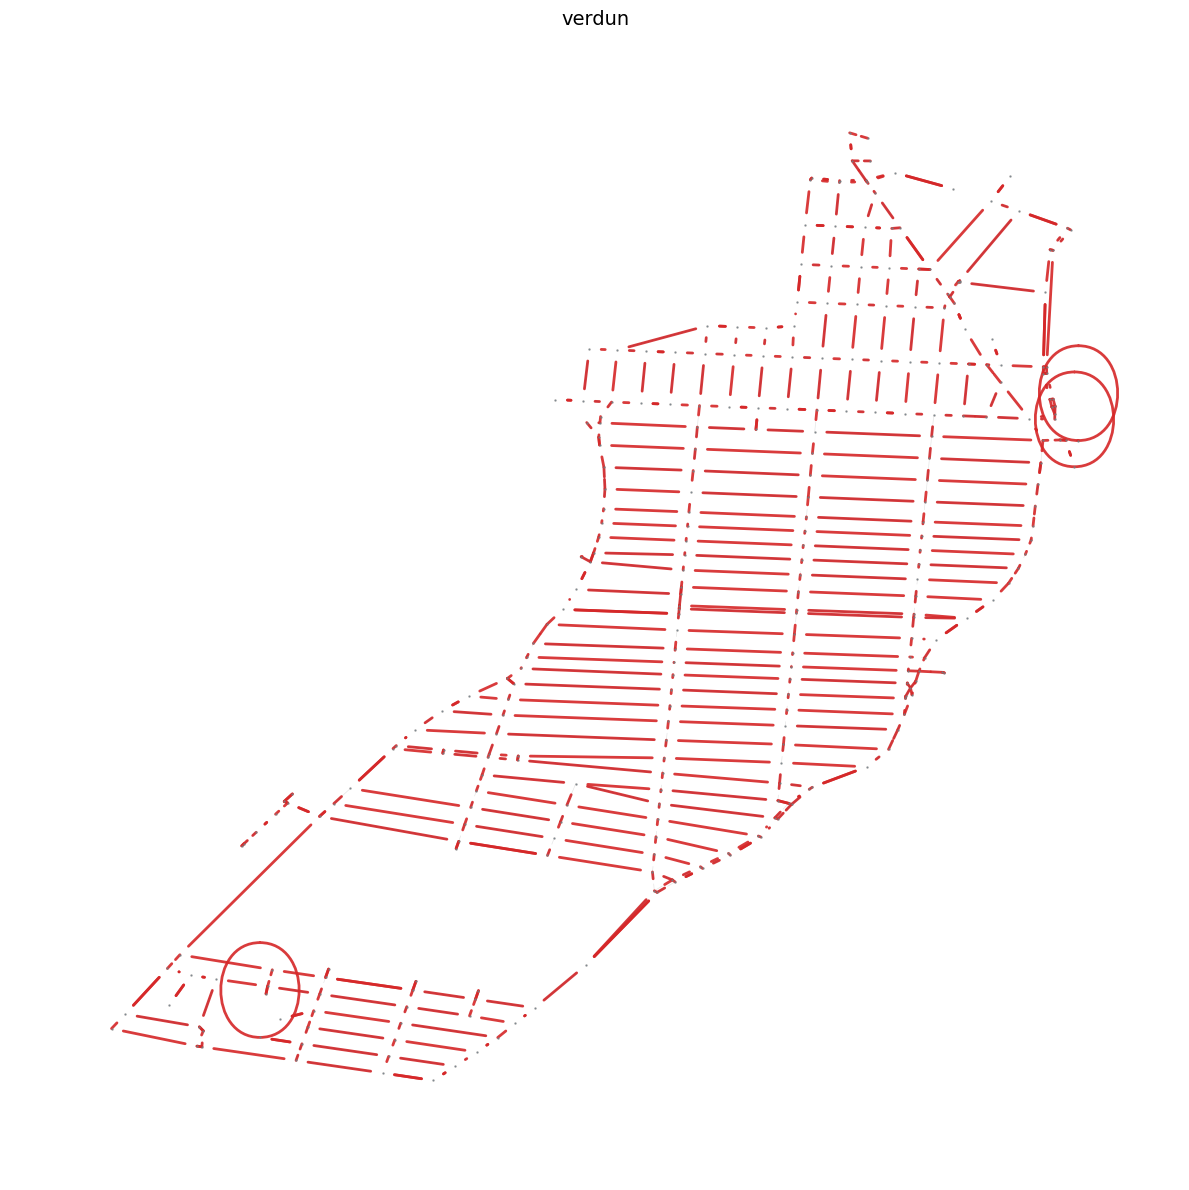

In [136]:
animation_import("verdun")

In [ ]:
animation_import("verdun")